# 06 — Análise Comparativa dos Resultados

Compara as 6 variantes de prompting (3 zero-shot × 3 few-shot) avaliadas no ToLD-Br.

- Métrica principal: **F1-macro**
- Saída: `results/metrics_summary.json`

In [1]:
import json
from pathlib import Path

import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    classification_report, f1_score, precision_score, recall_score, confusion_matrix
)

CATEGORIAS = ["homophobia", "insult", "misogyny", "not_toxic", "obscene", "racism", "xenophobia"]

EXPERIMENTOS_CONFIG = {
    "zs_v1_base":         ("../results/zero_shot_v1_base.csv",        "ZS-v1 Base",          "zero_shot"),
    "zs_v2_descriptions": ("../results/zero_shot_v2_descriptions.csv", "ZS-v2 Descriptions",  "zero_shot"),
    "zs_v3_no_antibias":  ("../results/zero_shot_v3_no_antibias.csv",  "ZS-v3 No-Antibias",   "zero_shot"),
    "fs_v1_1ex":          ("../results/few_shot_v1_1ex.csv",           "FS-v1 1-Example",     "few_shot"),
    "fs_v2_2ex_antibias": ("../results/few_shot_v2_2ex_antibias.csv",  "FS-v2 2ex+Antibias",  "few_shot"),
    "fs_v3_2ex":          ("../results/few_shot_v3_2ex.csv",           "FS-v3 2-Examples",    "few_shot"),
}

CORES = {
    "zero_shot": "#4C72B0",
    "few_shot":  "#DD8452",
}

experimentos = {}
for chave, (path, label, grupo) in EXPERIMENTOS_CONFIG.items():
    df = pl.read_csv(path).with_columns(pl.col("predicao").str.to_lowercase())
    unknown = (df["predicao"] == "unknown").sum()
    print(f"{label:<22}: {len(df)} tweets | unknown={unknown}")
    experimentos[chave] = df

ZS-v1 Base            : 500 tweets | unknown=0
ZS-v2 Descriptions    : 500 tweets | unknown=0
ZS-v3 No-Antibias     : 500 tweets | unknown=0
FS-v1 1-Example       : 500 tweets | unknown=0
FS-v2 2ex+Antibias    : 500 tweets | unknown=0
FS-v3 2-Examples      : 500 tweets | unknown=0


## F1-macro por estratégia

In [2]:
metricas = {}

for chave, df in experimentos.items():
    _, label, grupo = EXPERIMENTOS_CONFIG[chave]
    y_true = df["label"].to_list()
    y_pred = df["predicao"].to_list()
    metricas[chave] = {
        "label": label,
        "grupo": grupo,
        "f1_macro":        round(f1_score(y_true, y_pred, average="macro",    zero_division=0), 4),
        "f1_weighted":     round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "precision_macro": round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "recall_macro":    round(recall_score(y_true, y_pred,    average="macro", zero_division=0), 4),
        "per_class": {},
    }
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    for cat in CATEGORIAS:
        if cat in report:
            metricas[chave]["per_class"][cat] = {
                "f1":        round(report[cat]["f1-score"],  4),
                "precision": round(report[cat]["precision"], 4),
                "recall":    round(report[cat]["recall"],    4),
                "support":   int(report[cat]["support"]),
            }

print(f"{'Estratégia':<22} {'F1-macro':>10} {'F1-weighted':>12} {'Precision':>10} {'Recall':>8}")
print("-" * 66)
for chave, m in metricas.items():
    print(f"{m['label']:<22} {m['f1_macro']:>10.4f} {m['f1_weighted']:>12.4f} {m['precision_macro']:>10.4f} {m['recall_macro']:>8.4f}")

Estratégia               F1-macro  F1-weighted  Precision   Recall
------------------------------------------------------------------
ZS-v1 Base                 0.2347       0.7317     0.2519   0.2359
ZS-v2 Descriptions         0.2673       0.7050     0.2733   0.2913
ZS-v3 No-Antibias          0.2516       0.7197     0.2812   0.2647
FS-v1 1-Example            0.2994       0.7710     0.3254   0.2961
FS-v2 2ex+Antibias         0.2750       0.7712     0.2962   0.2868
FS-v3 2-Examples           0.2606       0.7659     0.2803   0.2734


## Ranking por F1-macro

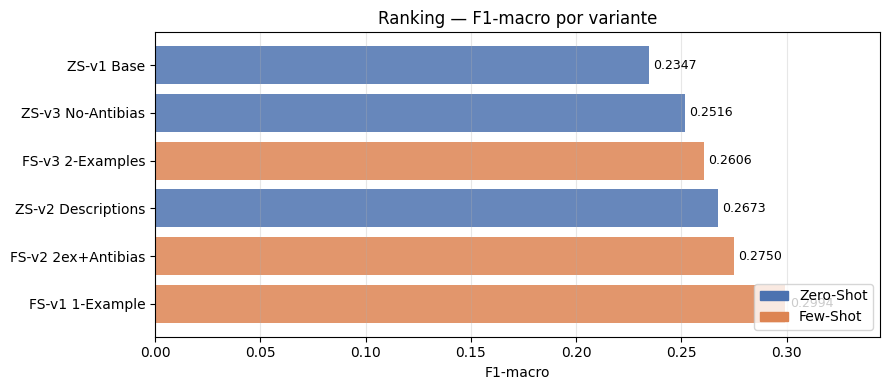


Melhor variante: FS-v1 1-Example — F1-macro=0.2994


In [3]:
ranking = sorted(metricas.items(), key=lambda x: x[1]["f1_macro"], reverse=True)

fig, ax = plt.subplots(figsize=(9, 4))
labels_r  = [m["label"] for _, m in ranking]
f1s_r     = [m["f1_macro"] for _, m in ranking]
cores_r   = [CORES[m["grupo"]] for _, m in ranking]

bars = ax.barh(labels_r, f1s_r, color=cores_r, alpha=0.85)
for bar, val in zip(bars, f1s_r):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2, f"{val:.4f}", va="center", fontsize=9)

ax.set_xlabel("F1-macro")
ax.set_title("Ranking — F1-macro por variante")
ax.set_xlim(0, max(f1s_r) * 1.15)
ax.grid(axis="x", alpha=0.3)

legend = [
    mpatches.Patch(color=CORES["zero_shot"], label="Zero-Shot"),
    mpatches.Patch(color=CORES["few_shot"],  label="Few-Shot"),
]
ax.legend(handles=legend, loc="lower right")

plt.tight_layout()
plt.savefig("../results/ranking_f1_macro.png", dpi=150)
plt.show()

melhor_chave, melhor_m = ranking[0]
print(f"\nMelhor variante: {melhor_m['label']} — F1-macro={melhor_m['f1_macro']:.4f}")

## F1 por categoria — todas as variantes

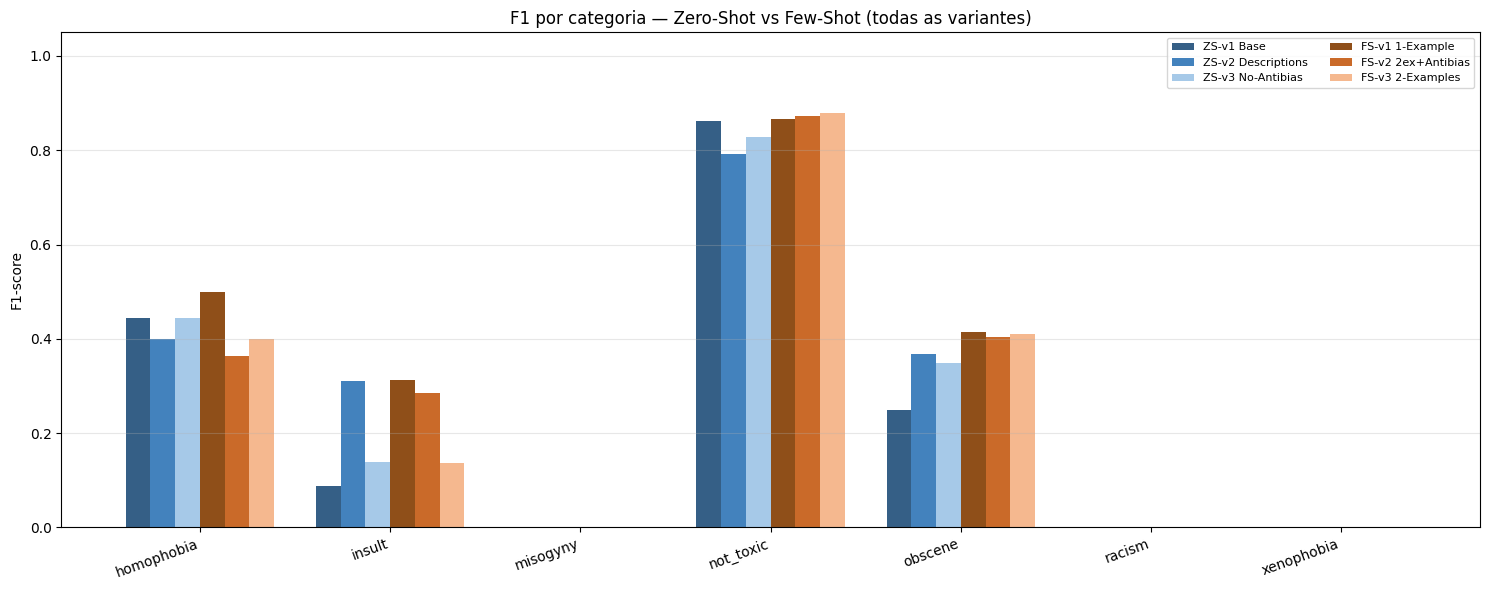

In [4]:
fig, ax = plt.subplots(figsize=(15, 6))

n = len(metricas)
x = np.arange(len(CATEGORIAS))
width = 0.13

paleta_zs = ["#1f4e79", "#2e75b6", "#9dc3e6"]
paleta_fs = ["#833c00", "#c55a11", "#f4b183"]
palettas  = paleta_zs + paleta_fs

for idx, (chave, m) in enumerate(metricas.items()):
    f1s = [m["per_class"].get(cat, {}).get("f1", 0) for cat in CATEGORIAS]
    offset = (idx - n / 2 + 0.5) * width
    ax.bar(x + offset, f1s, width, label=m["label"], color=palettas[idx], alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(CATEGORIAS, rotation=20, ha="right")
ax.set_ylabel("F1-score")
ax.set_ylim(0, 1.05)
ax.set_title("F1 por categoria — Zero-Shot vs Few-Shot (todas as variantes)")
ax.legend(fontsize=8, ncol=2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../results/f1_por_categoria.png", dpi=150)
plt.show()

## Matrizes de confusão — todas as variantes

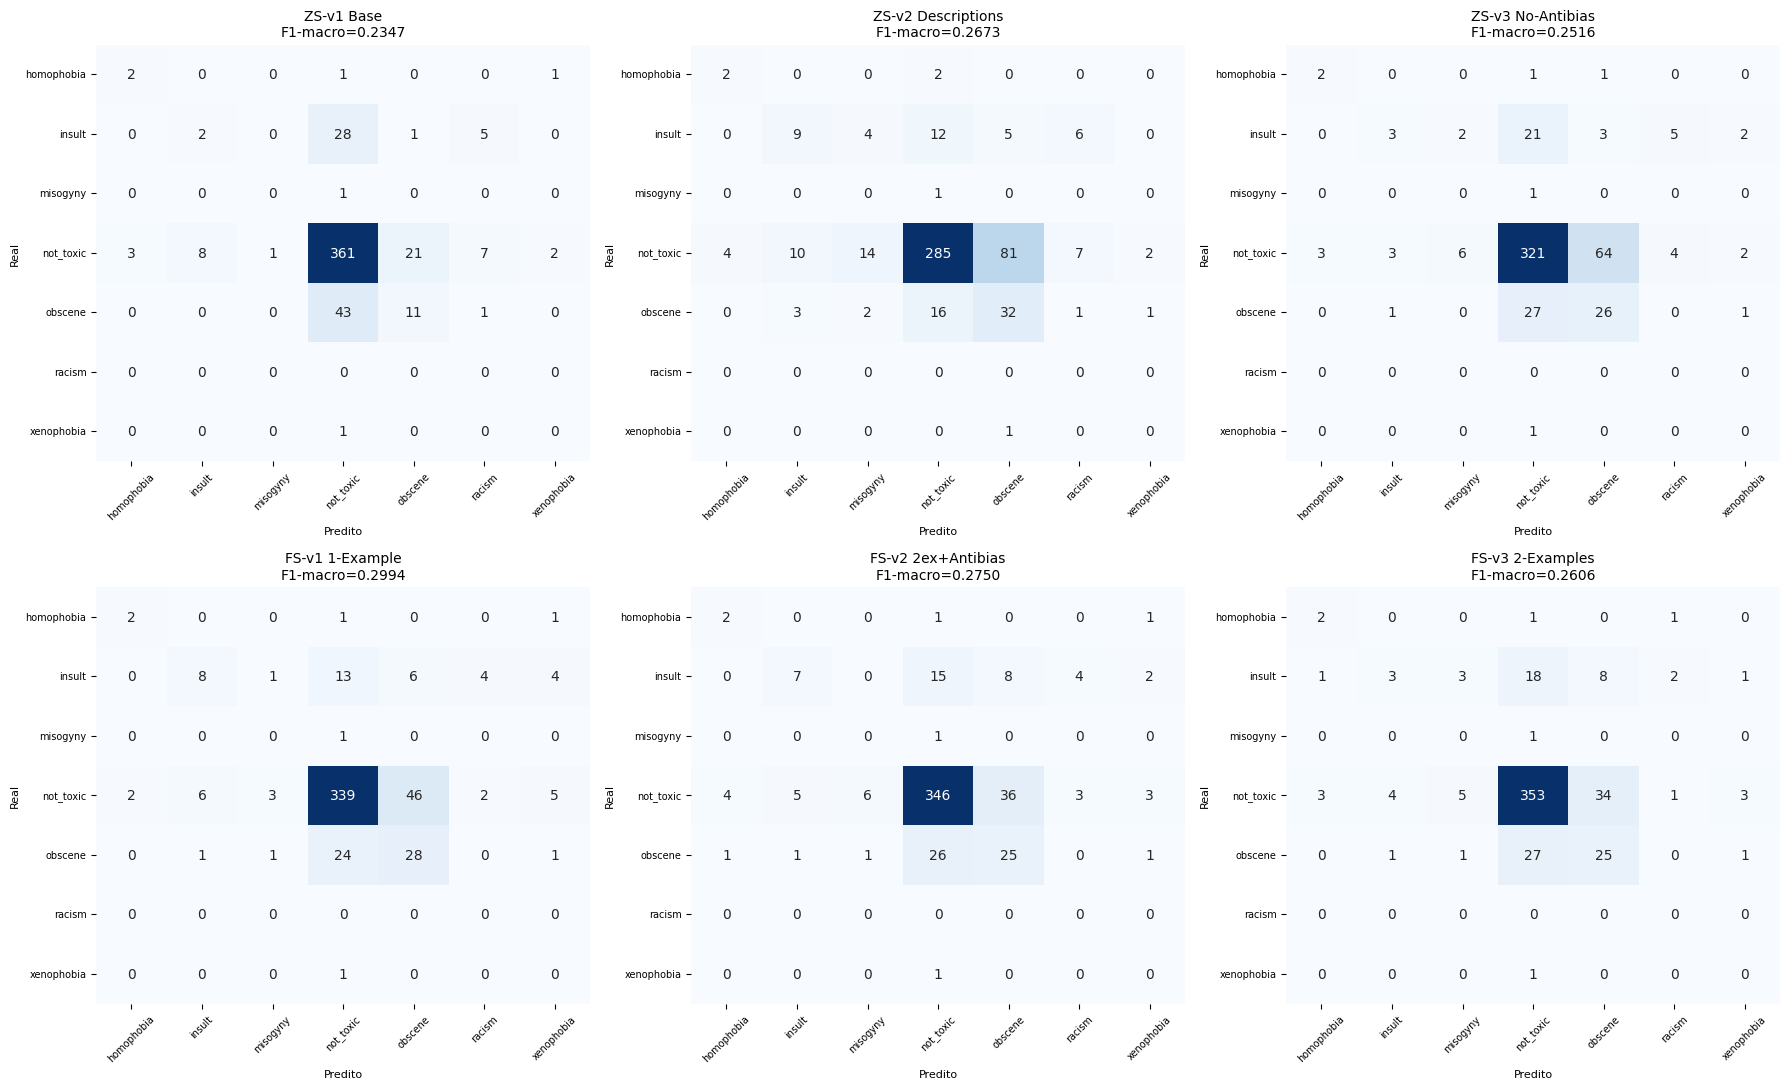

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for ax, (chave, df) in zip(axes.flatten(), experimentos.items()):
    m = metricas[chave]
    y_true = df["label"].to_list()
    y_pred = df["predicao"].to_list()
    cm = confusion_matrix(y_true, y_pred, labels=CATEGORIAS)
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=CATEGORIAS, yticklabels=CATEGORIAS,
                cmap="Blues", ax=ax, cbar=False)
    ax.set_xlabel("Predito", fontsize=8)
    ax.set_ylabel("Real", fontsize=8)
    ax.set_title(f"{m['label']}\nF1-macro={m['f1_macro']:.4f}", fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig("../results/confusion_matrices.png", dpi=150)
plt.show()

## Velocidade de inferência

In [6]:
print(f"{'Estratégia':<22} {'Tokens/s médio':>16} {'Tokens/s min':>14} {'Tokens/s max':>14}")
print("-" * 70)
for chave, df in experimentos.items():
    label = EXPERIMENTOS_CONFIG[chave][1]
    tps_mean = df["tokens_s"].mean()
    tps_min  = df["tokens_s"].min()
    tps_max  = df["tokens_s"].max()
    print(f"{label:<22} {tps_mean:>16.1f} {tps_min:>14.1f} {tps_max:>14.1f}")
    metricas[chave]["tokens_s_medio"] = round(tps_mean, 1)

Estratégia               Tokens/s médio   Tokens/s min   Tokens/s max
----------------------------------------------------------------------
ZS-v1 Base                        107.5           94.0          127.4
ZS-v2 Descriptions                106.7           91.3          127.1
ZS-v3 No-Antibias                 105.4           62.7          126.5
FS-v1 1-Example                   107.7           93.7          126.2
FS-v2 2ex+Antibias                107.0           92.2          128.3
FS-v3 2-Examples                  108.5           92.1          128.2


## Análise de discordâncias entre variantes

In [7]:
# Monta dataframe comparativo com todas as predições
base = experimentos["zs_v1_base"].select(["text", "label"])
df_comp = base
for chave, df in experimentos.items():
    df_comp = df_comp.with_columns(df["predicao"].alias(f"pred_{chave}"))

# Quantos tweets cada par de variantes concorda
chaves = list(experimentos.keys())
print("Taxa de concordância entre pares de variantes:")
print(f"{'Par':<45} {'Concordância':>12}")
print("-" * 59)
for i in range(len(chaves)):
    for j in range(i + 1, len(chaves)):
        a, b = chaves[i], chaves[j]
        la = EXPERIMENTOS_CONFIG[a][1]
        lb = EXPERIMENTOS_CONFIG[b][1]
        agree = (df_comp[f"pred_{a}"] == df_comp[f"pred_{b}"]).sum() / len(df_comp)
        print(f"{la:<22} × {lb:<22} {agree:>10.1%}")

Taxa de concordância entre pares de variantes:
Par                                           Concordância
-----------------------------------------------------------
ZS-v1 Base             × ZS-v2 Descriptions          70.4%
ZS-v1 Base             × ZS-v3 No-Antibias           78.0%
ZS-v1 Base             × FS-v1 1-Example             78.4%
ZS-v1 Base             × FS-v2 2ex+Antibias          80.2%
ZS-v1 Base             × FS-v3 2-Examples            80.0%
ZS-v2 Descriptions     × ZS-v3 No-Antibias           78.4%
ZS-v2 Descriptions     × FS-v1 1-Example             72.8%
ZS-v2 Descriptions     × FS-v2 2ex+Antibias          72.4%
ZS-v2 Descriptions     × FS-v3 2-Examples            73.0%
ZS-v3 No-Antibias      × FS-v1 1-Example             79.2%
ZS-v3 No-Antibias      × FS-v2 2ex+Antibias          79.8%
ZS-v3 No-Antibias      × FS-v3 2-Examples            79.2%
FS-v1 1-Example        × FS-v2 2ex+Antibias          84.4%
FS-v1 1-Example        × FS-v3 2-Examples            82.6%
FS-v2 2e

## Salvar resultados consolidados

In [8]:
# metrics_summary.json
with open("../results/metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(metricas, f, ensure_ascii=False, indent=2)
print("Salvo: results/metrics_summary.json")

# metrics_per_strategy.csv — uma linha por (estratégia × categoria)
rows = []
for chave, m in metricas.items():
    for cat in CATEGORIAS:
        pc = m["per_class"].get(cat, {})
        rows.append({
            "estrategia":   chave,
            "label":        m["label"],
            "grupo":        m["grupo"],
            "categoria":    cat,
            "f1":           pc.get("f1", 0.0),
            "precision":    pc.get("precision", 0.0),
            "recall":       pc.get("recall", 0.0),
            "support":      pc.get("support", 0),
            "f1_macro":     m["f1_macro"],
            "f1_weighted":  m["f1_weighted"],
        })
pl.DataFrame(rows).write_csv("../results/metrics_per_strategy.csv")
print("Salvo: results/metrics_per_strategy.csv")

# predictions_comparison.csv
df_comp.write_csv("../results/predictions_comparison.csv")
print("Salvo: results/predictions_comparison.csv")

print("\nRESUMO FINAL — ranking por F1-macro")
print("=" * 50)
for chave, m in sorted(metricas.items(), key=lambda x: x[1]["f1_macro"], reverse=True):
    print(f"{m['label']:<22}  F1-macro={m['f1_macro']:.4f}  F1-weighted={m['f1_weighted']:.4f}")

Salvo: results/metrics_summary.json
Salvo: results/metrics_per_strategy.csv
Salvo: results/predictions_comparison.csv

RESUMO FINAL — ranking por F1-macro
FS-v1 1-Example         F1-macro=0.2994  F1-weighted=0.7710
FS-v2 2ex+Antibias      F1-macro=0.2750  F1-weighted=0.7712
ZS-v2 Descriptions      F1-macro=0.2673  F1-weighted=0.7050
FS-v3 2-Examples        F1-macro=0.2606  F1-weighted=0.7659
ZS-v3 No-Antibias       F1-macro=0.2516  F1-weighted=0.7197
ZS-v1 Base              F1-macro=0.2347  F1-weighted=0.7317
